## <strong> 11. 시계열 전용 연산

필요한 라이브러리: ```yfinance```, ```pandas_datareader```

In [1]:
!pip install yfinance

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------------ --------------------------- 0.5/1.7 MB 2.3 MB/s eta 0:00:01
   ------------------------------- -------- 1.3/1.7 MB 3.0 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 3.1 MB/s eta 0:00:00

   ---------------------------------------- 0/6 [peewee]
   ---------------------------------------- 0/6 [peewee]
   ---------------------------------------- 0/6 [peewee]
   ------------- -------------------------- 2/6 [websockets]
   ------------- -------------------------- 2/6 [websockets]
   ------------- -------------------------- 2/6 [websockets]
   ------------- -------------------------- 2/6 [websockets]
  Attempting uninstall: cffi
   ------------- -------------------------- 2/6 [websockets]
    Found existing installation: cffi 1.17.1
   ------------- -------------------------- 2/6 [websockets]
   -------------------- ------------------- 3/6 [cffi]
    Uninstalling cffi-1.17.1:
   ---

In [2]:
import yfinance as yf
import pandas as pd
from matplotlib import pyplot as plt

In [3]:
# 구글 주식 데이터 로딩
goog = yf.download("GOOG", start="2004-01-01", end="2024-12-31")
goog.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG
Date,,,,,
2004-08-19,2.478783,2.570680,2.370580,2.470383,897427216
2004-08-20,2.675672,2.694694,2.482735,2.495333,458857488
2004-08-23,2.702599,2.803390,2.693953,2.735949,366857939
2004-08-24,2.590690,2.756947,2.558575,2.748054,306396159
2004-08-25,2.618606,2.668014,2.566233,2.592914,184645512


In [ ]:
# [+] 종가(Close) 데이터만 사용하기
goog = ...
goog

In [4]:
# [+] Lineplot 시각화
goog.plot

#### <strong> 리샘플링(Resampling)
+ ```resample()```: 빈도를 기준으로 집계 연산
+ ```asfreq()```: 빈도 단위 별 데이터 선택

In [ ]:
# [+] 다운샘플링: resample()
goog_downsampled = ...
goog_downsampled

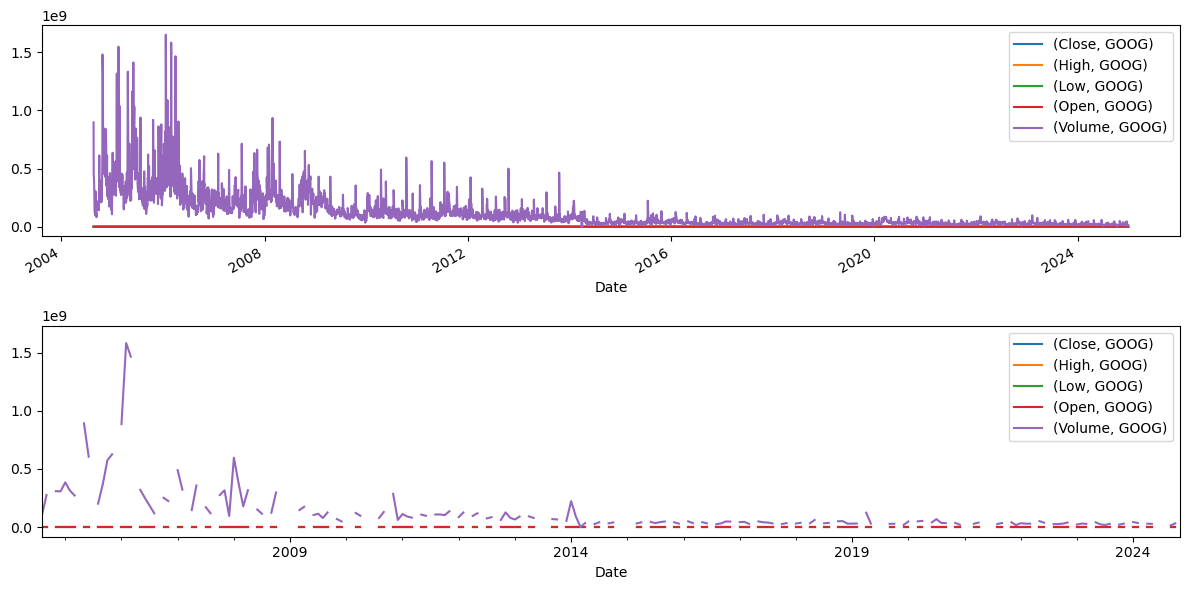

In [6]:
fig, ax = plt.subplots(2, 1, sharey=True, figsize=(12, 6))
goog.plot(label='original', ax=ax[0])
ax[0].legend()
goog_downsampled.plot(label='downsampled', ax=ax[1])
ax[1].legend()
plt.tight_layout()

C:\Users\cch03\AppData\Local\Temp\ipykernel_19960\2305263628.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  goog_downsampled = goog.asfreq('M')


Price            Close        High         Low        Open       Volume
Ticker            GOOG        GOOG        GOOG        GOOG         GOOG
Date                                                                   
2004-08-31    2.528930    2.562033    2.523743    2.527202   98825037.0
2004-09-30    3.201616    3.268317    3.186794    3.209027  276468402.0
2004-10-31         NaN         NaN         NaN         NaN          NaN
2004-11-30    4.495602    4.520800    4.452865    4.464228  309154460.0
2004-12-31    4.762652    4.937802    4.756969    4.921745  307889737.0
...                ...         ...         ...         ...          ...
2024-07-31  171.935455  174.676105  170.515493  173.693044   15650200.0
2024-08-31         NaN         NaN         NaN         NaN          NaN
2024-09-30  166.235825  166.404853  163.700375  163.839575   14070100.0
2024-10-31  171.704422  177.401715  171.575159  173.722835   32801900.0
2024-11-30         NaN         NaN         NaN         NaN      

<Axes: xlabel='Date'>

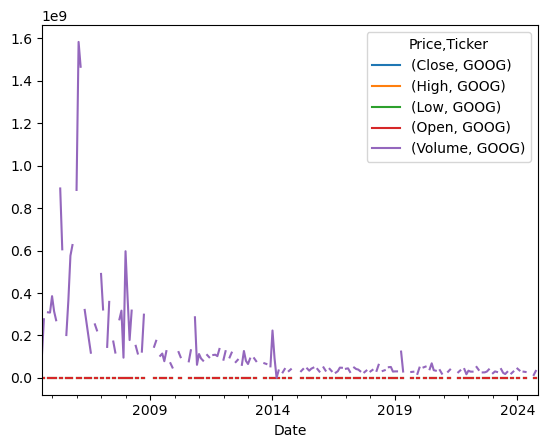

In [5]:
# [+] 다운샘플링: asfreq()
goog_downsampled = goog.asfreq('M')
print(goog_downsampled)

goog_downsampled.plot()

In [10]:
# [+] 업샘플링: resample()
goog_upsampled = goog.resample ('12h').mean()
print(goog_upsampled)

Price                     Close        High         Low        Open  \
Ticker                     GOOG        GOOG        GOOG        GOOG   
Date                                                                  
2004-08-19 00:00:00    2.478783    2.570680    2.370580    2.470383   
2004-08-19 12:00:00         NaN         NaN         NaN         NaN   
2004-08-20 00:00:00    2.675672    2.694694    2.482735    2.495333   
2004-08-20 12:00:00         NaN         NaN         NaN         NaN   
2004-08-21 00:00:00         NaN         NaN         NaN         NaN   
...                         ...         ...         ...         ...   
2024-12-28 00:00:00         NaN         NaN         NaN         NaN   
2024-12-28 12:00:00         NaN         NaN         NaN         NaN   
2024-12-29 00:00:00         NaN         NaN         NaN         NaN   
2024-12-29 12:00:00         NaN         NaN         NaN         NaN   
2024-12-30 00:00:00  191.807632  192.892637  189.488300  189.990993   

Price

#### <strong> 시프팅(Shifting)
+ ```shift(periods)``` : ```periods``` 값 만큼 시계열 이동

In [ ]:
# [+] 900일 뒤로 시프팅 적용
goog_shifted = goog.shi
goog_shifted

NameError: name 'goog_shifted' is not defined

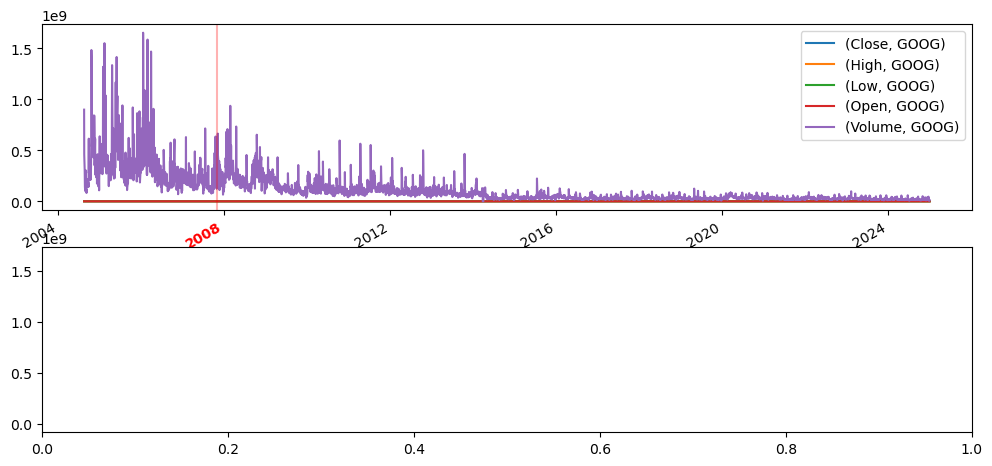

In [7]:
fig, ax = plt.subplots(2, 1, sharey=True, figsize=(12, 6))

# Legends and annotations
local_max = pd.to_datetime('2007-11-05')
offset = pd.Timedelta(900, 'D')

goog.plot(label='original', ax=ax[0])
ax[0].legend()
ax[0].get_xticklabels()[2].set(weight='heavy', color='red')
ax[0].axvline(local_max, alpha=0.3, color='red')

goog_shifted.plot(label='shifted 900 days', ax=ax[1])
ax[1].legend()
ax[1].get_xticklabels()[2].set(weight='heavy', color='red')
ax[1].axvline(local_max + offset, alpha=0.3, color='red')

plt.tight_layout()

In [9]:
# shifting 응용: 주가 변화율 계산
goog_shifted = goog.shift(periods=1) # [+] 시프팅
(goog - goog_shifted) / (goog_shifted)# [+] 주가 변화율 계산

Price,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG
Date,,,,,
2004-08-19,NaN,NaN,NaN,NaN,NaN
2004-08-20,0.079430,0.048242,0.047311,0.010100,-0.488697
2004-08-23,0.010064,0.040337,0.085075,0.096426,-0.200497
2004-08-24,-0.041408,-0.016567,-0.050252,0.004424,-0.164810
2004-08-25,0.010775,-0.032258,0.002993,-0.056455,-0.397363
...,...,...,...,...,...
2024-12-23,0.015703,0.012131,0.028224,0.037538,-0.663813
2024-12-24,0.008062,0.006005,0.018619,0.011029,-0.553042


In [ ]:
# shifting 응용: 차분 시계열 구하기
goog_diff = ...  # [+] 차분
print(goog_diff)

goog_diff.plot()

#### <strong> 윈도잉(Windowing)

In [ ]:
# [+] 365일 단위 윈도잉
goog_rolled = ...
print(goog_rolled)

goog_rolled.mean().plot()

In [ ]:
data = pd.DataFrame({'input': goog.values.flatten(),
                     # moving average
                     'one-year rolling_mean': goog_rolled.mean().values.flatten(), 
                     # standard deviation
                     'one-year rolling_std': goog_rolled.std().values.flatten()}, index=goog.index)
ax = data.plot(style=['-', '--', ':'])
ax.lines[0].set_alpha(0.3)